## Литература
Application of machine learning algorithms for population forecasting, 2021

The target variable is determined as the total population value of 2017. Валидацию делали на Турции.

Здесь мы будем предсказывать на 10 лет вперёд, целевая переменная будет численность населения 2013-2022 включительно. Здесь мы делаем валидацию на России без учёта Крыма.

## Baseline
### Naïve (Last Observation)

Официальный базовый метод временных рядов (Hyndman & Athanasopoulos, *Forecasting*).

**Формула:**

\[
\hat{y}_{t+h} = y_t
\]

Прогноз равен последнему известному значению.

**Почему это baseline:**  
Любая модель должна быть лучше сценария «ничего не меняется». В демографии тренды часто инерционные, поэтому такой тест особенно важен.

Синонимы: **Naïve Forecast**, **Last Value Forecast**.

---

### 2) Linear Trend (OLS Extrapolation)

Классический демографический базовый метод для сравнения со сложными моделями.

**Модель:**

\[
y_t = a + b t
\]

Подгоняется по обучающему отрезку, затем линейно экстраполируется на годы \(t+1,\ldots,t+H\).

**Почему используется:**  
Демографические организации (UN, Eurostat) приводят линейную аппроксимацию как технический среднесрочный ориентир и минимальный структурный baseline.

Название: **Linear Trend Extrapolation**.


### Метрики для сравнения моделей
Взяты из статьи 
#### 1) MAPE (Mean Absolute Percentage Error)

\[
\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|
\]


#### 2) RMSE (Root Mean Squared Error)
\[
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\]


### 3) SDEV ошибок (стандартное отклонение абсолютных ошибок)
Нужно для анализа стабильности модели между странами и годами.  
MAPE может быть одинаковым у двух моделей, но одна стабильна, а другая «стреляющая» — SDEV это показывает.
\[
\text{SDEV} = \sqrt{\frac{1}{n}\sum_{i=1}^n (e_i - \bar{e})^2}
\]
где \(e_i = |y_i - \hat{y}_i|\).


### 3 Rolling Windows

Для оценки стабильности моделей по времени используются три окна:

1. **Окно A:** train до 1999, тест 2000–2009  
2. **Окно B:** train до 2004, тест 2005–2014  
3. **Окно C:** train до 2012, тест 2013–2022  

Каждое окно покрывает 10 лет прогнозирования. Три окна позволяют проверить, насколько модели устойчивы к различным историческим периодам, выявить зависимость качества прогнозов от трендов и колебаний населения. Такой подход имитирует скользящий forecast, что часто применяют в демографии для оценки краткосрочной и среднесрочной точности моделей.

In [1]:
import pandas as pd
import numpy as np

df_pop = pd.read_csv("final/filtered_25_predict10_pop.csv")
df_filtered =  pd.read_csv("final/filtered_25_predict10_noncohort.csv")
df_just_pop = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])
df_all =  pd.read_csv("final/filtered_25_predict10_all.csv")

#df = pd.read_csv("output/merged_worldbank_long_no_nan.csv")
def naive_forecast(train_series, horizon):
    last_value = train_series.iloc[-1]
    return np.array([last_value] * horizon)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def rmse_perc(y_true, y_pred):
    rmse_val = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse_val / np.mean(y_true)

def sdev_perc(y_true, y_pred):
    e = np.abs(y_true - y_pred)
    return e.std() / np.mean(y_true)

models_results = {}
def print_model_summary(model_name):
    for train_type, metrics in models_results.get(model_name, {}).items():
        print(f"\n=== Model: {model_name} | Train type: {train_type} ===")
        line = f"MAPE={metrics.get('MAPE', float('nan')):.3f}, " \
               f"RMSE={metrics.get('RMSE', float('nan')):.3f}, " \
               f"SDEV={metrics.get('SDEV', float('nan')):.3f}"
        print(line)


Что если искать без признаков(без значений за 25 лет)

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

model_name = "linear_regression"
models_results[model_name] = {}

train_start, train_end = 1960, 2012  # train до 2012
test_start, test_end = 2013, 2022    # предсказываем 2013–2022
horizon = test_end - test_start + 1

models_results[model_name]["just_population"] = {}

countries = df_just_pop["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

for c in countries:
    d = df_just_pop[df_just_pop["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    X_train = d_train["year"].values.reshape(-1, 1)
    y_train = d_train["Population_total"].values
    X_test = d_test["year"].values.reshape(-1, 1)
    y_test = d_test["Population_total"].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    m_mape = mape(y_test, y_pred)
    m_rmse = rmse_perc(y_test, y_pred)
    m_sdev = sdev_perc(y_test, y_pred)

    res_map["MAPE"].append(m_mape)
    res_map["RMSE"].append(m_rmse)
    res_map["SDEV"].append(m_sdev)

models_results[model_name]["just_population"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary("linear_regression")



=== Model: linear_regression | Train type: just_population ===
MAPE=0.095, RMSE=0.099, SDEV=0.022


In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

model_name = "linear_regression"

dfm = df_pop.copy()
dfm = dfm.sort_values(["country_code", "year"])

DATA_RANGE = 25
PREDICT_RANGE = 10
target_shift = DATA_RANGE + PREDICT_RANGE

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = f"pop_plus_{target_shift}"
horizon = test_end - test_start + 1

models_results[model_name]["population"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    X_train = d_train[feature_cols].values
    X_test  = d_test[feature_cols].values

    y_train = d_train[target_column].values
    y_test  = d_test[target_column].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res_map["MAPE"].append(mape(y_test, y_pred))
    res_map["RMSE"].append(rmse_perc(y_test, y_pred))
    res_map["SDEV"].append(sdev_perc(y_test, y_pred))

models_results[model_name]["population"] = {
    "MAPE": float(np.mean(res_map["MAPE"])) if len(res_map["MAPE"])>0 else float("nan"),
    "RMSE": float(np.mean(res_map["RMSE"])) if len(res_map["RMSE"])>0 else float("nan"),
    "SDEV": float(np.mean(res_map["SDEV"])) if len(res_map["SDEV"])>0 else float("nan")
}

print_model_summary("linear_regression")



=== Model: linear_regression | Train type: just_population ===
MAPE=0.095, RMSE=0.099, SDEV=0.022

=== Model: linear_regression | Train type: population ===
MAPE=0.106, RMSE=0.130, SDEV=0.072


In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

model_name = "linear_regression"

dfm = df_filtered.copy()
dfm = dfm.sort_values(["country_code", "year"])


models_results[model_name]["filtered"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
dropped_counts = []

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    dropped_cols = [col for col in feature_cols if d_test[col].isna().any()]
    feature_cols = [col for col in feature_cols if not d_test[col].isna().any()]
    dropped_counts.append(len(dropped_cols))

    X_train = d_train[feature_cols].values
    X_test  = d_test[feature_cols].values
    y_train = d_train[target_column].values
    y_test  = d_test[target_column].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res_map["MAPE"].append(mape(y_test, y_pred))
    res_map["RMSE"].append(rmse_perc(y_test, y_pred))
    res_map["SDEV"].append(sdev_perc(y_test, y_pred))

mean_dropped = np.mean(dropped_counts)

models_results[model_name]["filtered"] = {
    "MAPE": float(np.mean(res_map["MAPE"])) if len(res_map["MAPE"])>0 else float("nan"),
    "RMSE": float(np.mean(res_map["RMSE"])) if len(res_map["RMSE"])>0 else float("nan"),
    "SDEV": float(np.mean(res_map["SDEV"])) if len(res_map["SDEV"])>0 else float("nan")
}

print("Среднее количество отсеянных колонок по странам:", mean_dropped)
print_model_summary("linear_regression")


Среднее количество отсеянных колонок по странам: 15.323671497584542

=== Model: linear_regression | Train type: just_population ===
MAPE=0.095, RMSE=0.099, SDEV=0.022

=== Model: linear_regression | Train type: population ===
MAPE=0.106, RMSE=0.130, SDEV=0.072

=== Model: linear_regression | Train type: filtered ===
MAPE=0.040, RMSE=0.051, SDEV=0.029


In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

model_name = "linear_regression"
df_all =  pd.read_csv("final/filtered_25_predict10_all.csv")
dfm = df_all.copy()
dfm = dfm.sort_values(["country_code", "year"])


models_results[model_name]["filtered_with_cohort"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
dropped_counts = []

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    dropped_cols = [col for col in feature_cols if d_test[col].isna().any()]
    feature_cols = [col for col in feature_cols if not d_test[col].isna().any()]
    dropped_counts.append(len(dropped_cols))

    X_train = d_train[feature_cols].values
    X_test  = d_test[feature_cols].values
    y_train = d_train[target_column].values
    y_test  = d_test[target_column].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res_map["MAPE"].append(mape(y_test, y_pred))
    res_map["RMSE"].append(rmse_perc(y_test, y_pred))
    res_map["SDEV"].append(sdev_perc(y_test, y_pred))

mean_dropped = np.mean(dropped_counts)

models_results[model_name]["filtered_with_cohort"] = {
    "MAPE": float(np.mean(res_map["MAPE"])) if len(res_map["MAPE"])>0 else float("nan"),
    "RMSE": float(np.mean(res_map["RMSE"])) if len(res_map["RMSE"])>0 else float("nan"),
    "SDEV": float(np.mean(res_map["SDEV"])) if len(res_map["SDEV"])>0 else float("nan")
}

print("Среднее количество отсеянных колонок по странам:", mean_dropped)
print_model_summary("linear_regression")


Среднее количество отсеянных колонок по странам: 322.80193236714973

=== Model: linear_regression | Train type: just_population ===
MAPE=0.095, RMSE=0.099, SDEV=0.022

=== Model: linear_regression | Train type: population ===
MAPE=0.106, RMSE=0.130, SDEV=0.072

=== Model: linear_regression | Train type: filtered ===
MAPE=0.040, RMSE=0.051, SDEV=0.029

=== Model: linear_regression | Train type: filtered_with_cohort ===
MAPE=0.027, RMSE=0.034, SDEV=0.020


In [22]:
import numpy as np
import pandas as pd

model_name = "naive"
models_results[model_name] = {}

dfm = df_pop.copy()
dfm = dfm.sort_values(["country_code", "year"])

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = "pop_plus_35"
horizon = test_end - test_start + 1

models_results[model_name]["population"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    y_train = d_train[target_column].values
    y_test = d_test[target_column].values

    y_pred = np.full(horizon, d_test["pop_plus_25"].values[0])

    m_mape = mape(y_test, y_pred)
    m_rmse = rmse_perc(y_test, y_pred)
    m_sdev = sdev_perc(y_test, y_pred)

    res_map["MAPE"].append(m_mape)
    res_map["RMSE"].append(m_rmse)
    res_map["SDEV"].append(m_sdev)

models_results[model_name]["population"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary(model_name)



=== Model: naive | Train type: population ===
MAPE=0.196, RMSE=0.202, SDEV=0.041


Попробуем взять чисто Population

In [23]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

model_name = "xgboost"
models_results[model_name] = {}

dfm = df_pop.copy()
dfm = dfm.sort_values(["country_code", "year"])

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = "pop_plus_35"
horizon = test_end - test_start + 1

models_results[model_name]["population"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    # отбрасываем колонки, где в тесте есть NaN
    feature_cols = [col for col in feature_cols if not d_test[col].isna().any()]

    X_train = d_train[feature_cols].values
    X_test = d_test[feature_cols].values
    y_train = d_train[target_column].values
    y_test = d_test[target_column].values

    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res_map["MAPE"].append(mape(y_test, y_pred))
    res_map["RMSE"].append(rmse_perc(y_test, y_pred))
    res_map["SDEV"].append(sdev_perc(y_test, y_pred))

models_results[model_name]["population"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary(model_name)



=== Model: xgboost | Train type: population ===
MAPE=0.079, RMSE=0.091, SDEV=0.041


In [24]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

model_name = "xgboost"
models_results[model_name] = {}

dfm = df_filtered.copy()
dfm = dfm.sort_values(["country_code", "year"])

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = "pop_plus_35"
horizon = test_end - test_start + 1

models_results[model_name]["filtered"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
dropped_counts = []

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    dropped_cols = [col for col in feature_cols if d_test[col].isna().any()]
    feature_cols = [col for col in feature_cols if not d_test[col].isna().any()]
    dropped_counts.append(len(dropped_cols))

    X_train = d_train[feature_cols].values
    X_test = d_test[feature_cols].values
    y_train = d_train[target_column].values
    y_test = d_test[target_column].values

    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    m_mape = mape(y_test, y_pred)
    m_rmse = rmse_perc(y_test, y_pred)
    m_sdev = sdev_perc(y_test, y_pred)

    res_map["MAPE"].append(m_mape)
    res_map["RMSE"].append(m_rmse)
    res_map["SDEV"].append(m_sdev)

mean_dropped = np.mean(dropped_counts)

models_results[model_name]["filtered"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary(model_name)



=== Model: xgboost | Train type: filtered ===
MAPE=0.079, RMSE=0.091, SDEV=0.041


In [29]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

model_name = "xgboost"

dfm = df_all.copy()
dfm = dfm.sort_values(["country_code", "year"])

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = "pop_plus_35"
horizon = test_end - test_start + 1

models_results[model_name]["filtered_all"] = {}

countries = dfm["country_code"].unique()

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
dropped_counts = []

for c in countries:
    d = dfm[dfm["country_code"] == c]
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    feature_cols = [col for col in dfm.columns if col not in ["country_code", target_column]]
    dropped_cols = [col for col in feature_cols if d_test[col].isna().any()]
    feature_cols = [col for col in feature_cols if not d_test[col].isna().any()]
    dropped_counts.append(len(dropped_cols))

    X_train = d_train[feature_cols].values
    X_test = d_test[feature_cols].values
    y_train = d_train[target_column].values
    y_test = d_test[target_column].values

    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    m_mape = mape(y_test, y_pred)
    m_rmse = rmse_perc(y_test, y_pred)
    m_sdev = sdev_perc(y_test, y_pred)

    res_map["MAPE"].append(m_mape)
    res_map["RMSE"].append(m_rmse)
    res_map["SDEV"].append(m_sdev)

mean_dropped = np.mean(dropped_counts)

models_results[model_name]["filtered_all"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary(model_name)



=== Model: xgboost | Train type: filtered_all ===
MAPE=0.079, RMSE=0.091, SDEV=0.041


In [25]:
import pandas as pd
from prophet import Prophet
import logging
for name in ("cmdstanpy", "prophet", "pystan", "httpstan"):
    lg = logging.getLogger(name)
    lg.handlers = []
    lg.propagate = False
    lg.setLevel(logging.CRITICAL)
df = df_just_pop.copy()
df = df.sort_values(["country_code", "year"])

train_end_year = 2012
test_start, test_end = 2013, 2022
target_column = "Population_total"

models_results['prophet'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

countries = df['country_code'].unique()
skipped_countries = set()
for c in countries:
    d = df[df['country_code'] == c].copy()

    d_train = d[d['year'] <= train_end_year]
    d_test = d[(d['year'] >= test_start) & (d['year'] <= test_end)]

    if len(d_train) == 0 or len(d_test) != (test_end - test_start + 1):
        skipped_countries.add(c)
        continue

    prophet_df = d_train.rename(columns={"year": "ds", target_column: "y"})

    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.fit(prophet_df)

    future = pd.DataFrame({"ds": d_test["year"]})
    forecast = model.predict(future)

    y_pred = forecast["yhat"].values
    y_test = d_test[target_column].values

    res_map["MAPE"].append(mape(y_test, y_pred))
    res_map["RMSE"].append(rmse_perc(y_test, y_pred))
    res_map["SDEV"].append(sdev_perc(y_test, y_pred))

models_results['prophet']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary('prophet')
print("skipped countries size: ", len(skipped_countries))



=== Model: prophet | Train type: population ===
MAPE=0.030, RMSE=0.034, SDEV=0.014
skipped countries size:  0


Посчитаем для Афганистана

In [26]:
import pandas as pd
from prophet import Prophet

df = df_just_pop.copy()
df = df.sort_values(["country_code", "year"])

train_end_year = 2012
test_start, test_end = 2013, 2022
target_column = "Population_total"

country = "AFG"

d = df[df["country_code"] == country].copy()
d_train = d[d["year"] <= train_end_year]
d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

prophet_df = d_train.rename(columns={"year": "ds", target_column: "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"].astype(str) + "-01-01")

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model.fit(prophet_df)

future = pd.DataFrame({"ds": pd.to_datetime(d_test["year"].astype(str) + "-01-01")})
forecast = model.predict(future)

y_pred = forecast["yhat"].values
y_true = d_test[target_column].values

print("AFG y_pred 2013–2022:")
print(y_pred)

print("AFG y_true 2013–2022:")
print(y_true)


AFG y_pred 2013–2022:
[30771395.55829204 31570345.90013357 32369296.2419751  33168246.58381662
 33969385.83070429 34768336.17254582 35567286.51438735 36366236.85622888
 37167376.10311656 37966326.44495808]
AFG y_true 2013–2022:
[31622704. 32792523. 33831764. 34700612. 35688935. 36743039. 37856121.
 39068979. 40000412. 40578842.]


Поподбираем лучшие параметры для Афганистана

In [27]:
import numpy as np
import pandas as pd
from prophet import Prophet
from itertools import product

df = df_just_pop.copy()
df = df.sort_values(["country_code", "year"])

train_end_year = 2012
test_start, test_end = 2013, 2022
target_column = "Population_total"

country = "AFG"
d = df[df["country_code"] == country].copy()
d_train = d[d["year"] <= train_end_year]
d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]

prophet_train = d_train.rename(columns={"year": "ds", target_column: "y"})
prophet_train["ds"] = pd.to_datetime(prophet_train["ds"].astype(str) + "-01-01")
future_test = pd.DataFrame({"ds": pd.to_datetime(d_test["year"].astype(str) + "-01-01")})

val_years = max(3, int(len(prophet_train) * 0.2))
d_val = prophet_train.tail(val_years)
d_fit = prophet_train.head(len(prophet_train) - val_years)

grid = {
    "changepoint_prior_scale": [0.025, 0.05, 0.1],
    "seasonality_prior_scale": [1.0, 3.0],
    "changepoint_range": [0.8, 0.95]
}
param_sets = list(product(grid["changepoint_prior_scale"], grid["seasonality_prior_scale"], grid["changepoint_range"]))

seasonality_mode_fixed = "additive"
best_mape = 999999
best_params = None

for cps, sps, cpr in param_sets:
    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode=seasonality_mode_fixed,
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            changepoint_range=cpr
        )
        m.fit(d_fit)
        fc = m.predict(d_val[["ds"]])
        y_true = d_val["y"].values
        y_pred = fc["yhat"].values
        cur_mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        if cur_mape < best_mape:
            best_mape = cur_mape
            best_params = {
                "changepoint_prior_scale": cps,
                "seasonality_prior_scale": sps,
                "changepoint_range": cpr
            }
    except:
        continue

if best_params is None:
    best_params = {
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0,
        "changepoint_range": 0.9
    }

m_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode=seasonality_mode_fixed,
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    changepoint_range=best_params["changepoint_range"]
)
m_final.fit(prophet_train)
forecast = m_final.predict(future_test)
y_pred = forecast["yhat"].values
y_true = d_test[target_column].values

print("Best parameters (seasonality fixed):", best_params)
print("AFG y_pred 2013–2022:", y_pred)
print("AFG y_true 2013–2022:", y_true)


Best parameters (seasonality fixed): {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 3.0, 'changepoint_range': 0.95}
AFG y_pred 2013–2022: [31000580.40174462 31851501.13964234 32713986.73792432 33587999.59039113
 34379305.26812335 35230226.00602099 36092711.6043033  36966724.45676995
 37758030.13450214 38608950.87239987]
AFG y_true 2013–2022: [31622704. 32792523. 33831764. 34700612. 35688935. 36743039. 37856121.
 39068979. 40000412. 40578842.]


Этот код выдаёт NaN много

In [28]:
import numpy as np
import pandas as pd
from prophet import Prophet
from itertools import product
from tqdm import tqdm
import logging
for name in ("cmdstanpy", "prophet", "pystan", "httpstan"):
    lg = logging.getLogger(name)
    lg.handlers = []
    lg.propagate = False
    lg.setLevel(logging.CRITICAL)
df = df_just_pop.copy()
df = df.sort_values(["country_code", "year"])

train_end_year = 2012
test_start, test_end = 2013, 2022
target_column = "Population_total"

grid = {
    "changepoint_prior_scale": [0.025, 0.05, 0.1],
    "seasonality_prior_scale": [1.0, 3.0],
    "changepoint_range": [0.8, 0.95]
}
param_sets = list(product(grid["changepoint_prior_scale"], grid["seasonality_prior_scale"], grid["changepoint_range"]))

seasonality_mode_fixed = "additive"

models_results = {}
models_results['prophet_grid'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
params_map = {}

countries = df['country_code'].unique()

for c in tqdm(countries, desc="Countries"):
    d = df[df['country_code'] == c].copy()
    d_train = d[d['year'] <= train_end_year]
    d_test  = d[(d['year'] >= test_start) & (d['year'] <= test_end)]

    if len(d_train) < 8 or len(d_test) != (test_end - test_start + 1):
        continue

    prophet_train = d_train.rename(columns={"year": "ds", target_column: "y"})
    prophet_train["ds"] = pd.to_datetime(prophet_train["ds"].astype(str) + "-01-01")
    future_test = pd.DataFrame({"ds": pd.to_datetime(d_test["year"].astype(str) + "-01-01")})

    val_years = max(3, int(len(prophet_train) * 0.2))
    d_val = prophet_train.tail(val_years)
    d_fit = prophet_train.head(len(prophet_train) - val_years)

    best_mape = 999999
    best_params = None

    for cps, sps, cpr in param_sets:
        try:
            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode=seasonality_mode_fixed,
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                changepoint_range=cpr
            )
            m.fit(d_fit)
            fc = m.predict(d_val[["ds"]])
            y_true = d_val["y"].values
            y_pred = fc["yhat"].values
            cur_mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            if cur_mape < best_mape:
                best_mape = cur_mape
                best_params = {"changepoint_prior_scale": cps, "seasonality_prior_scale": sps, "changepoint_range": cpr}
        except:
            continue

    if best_params is None:
        best_params = {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "changepoint_range": 0.9}

    params_map[c] = best_params

    m_final = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=seasonality_mode_fixed,
        changepoint_prior_scale=best_params["changepoint_prior_scale"],
        seasonality_prior_scale=best_params["seasonality_prior_scale"],
        changepoint_range=best_params["changepoint_range"]
    )
    m_final.fit(prophet_train)
    forecast = m_final.predict(future_test)

    y_pred = forecast["yhat"].values
    y_true = d_test[target_column].values

    mape_ = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse_ = (np.sqrt(np.mean((y_true - y_pred) ** 2)) / np.mean(y_true)) * 100
    sdev_ = np.std((y_true - y_pred) / y_true) * 100

    res_map["MAPE"].append(mape_)
    res_map["RMSE"].append(rmse_)
    res_map["SDEV"].append(sdev_)

    models_results['prophet_grid'][c] = {"forecast_2013_2022": y_pred.tolist()}

models_results['prophet_grid']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}
models_results['prophet_grid']['params'] = params_map


Countries:   0%|          | 0/207 [00:00<?, ?it/s]

Countries:  21%|██        | 43/207 [04:31<17:13,  6.30s/it]


KeyboardInterrupt: 

In [ ]:
print_model_summary("prophet_grid")


=== Model: prophet_grid | Train type: AFE ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AFG ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AFW ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AGO ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: ALB ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: ARB ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: ARE ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: ARG ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: ARM ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AUS ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AUT ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: AZE ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: prophet_grid | Train type: BDI ===
MAPE=nan, RMSE=nan, SDEV=nan

=== Model: 

### Когортная модель
Когортная модель демографии прогнозирует численность населения, разделённого по возрастным группам, учитывая выживаемость, рождаемость и миграцию. Каждая когорте переносится на следующий возраст, новорождённые рассчитываются через возрастные коэффициенты рождаемости женщин, смертность вычитается по возрастам, миграция распределяется пропорционально. Модель позволяет прогнозировать динамику населения с высокой детализацией.

Мы считаем для когорт 5-летних

In [30]:
models_results['cohort_component'] = {}

cohort_cols = [
    'POP0_4','POP5_9','POP10_14','POP15_19','POP20_24','POP25_29','POP30_34',
    'POP35_39','POP40_44','POP45_49','POP50_54','POP55_59','POP60_64',
    'POP65_69','POP70_74','POP75_79','POP80_84','POP85_89','POP90_94',
    'POP95_99','POP100PLUS'
]

mort_cols = [
    'mort_0_4','mort_5_9','mort_10_14','mort_15_19','mort_20_24','mort_25_29',
    'mort_30_34','mort_35_39','mort_40_44','mort_45_49','mort_50_54','mort_55_59',
    'mort_60_64','mort_65_69','mort_70_74','mort_75_79','mort_80_84','mort_85_89',
    'mort_90_94','mort_95_99','mort_100_100'
]

asfr_cols = [
    'asfr_10_14','asfr_15_19','asfr_20_24','asfr_25_29','asfr_30_34',
    'asfr_35_39','asfr_40_44','asfr_45_49','asfr_50_54'
]


fertile_cohorts = [
    'POP10_14','POP15_19','POP20_24','POP25_29','POP30_34',
    'POP35_39','POP40_44','POP45_49','POP50_54'
]

In [31]:
def get_births(cohort_vals, asfr_rates):
    absolute_cohorts = cohort_vals
    female_cohorts = absolute_cohorts / 2
    births = (female_cohorts * (asfr_rates / 1000)).sum()
    return births
def get_population_peoples(cohort_vals):
    return cohort_vals
def get_deaths_peoples(deaths_vals):
    return deaths_vals*1000

def shift_cohorts_one_year(pop_cohorts):
    """
    Считаем что в когорте люди распределены равномерно, поэтому при сдвиге на год 1/5 перемещается
    """
    n = len(pop_cohorts)
    new_cohorts = np.zeros_like(pop_cohorts)
    for i in range(1, n-1):
        new_cohorts[i] = pop_cohorts[i-1] * 0.2 + pop_cohorts[i] * 0.8
    new_cohorts[0] = 0.8*pop_cohorts[0]
    new_cohorts[-1] = pop_cohorts[-2] * 0.2 + pop_cohorts[-1]

    return new_cohorts

Для проверки логики посчитаем для Афганистана в 1960 году

In [32]:
import numpy as np
import pandas as pd

df = pd.read_csv("output/basic_with_cohort_filtered.csv")

afg_1960 = df[(df['country_code'] == 'AFG') & (df['year'] == 1960)]
population = afg_1960['Population_total'].iloc[0]

pop_cohorts = afg_1960[cohort_cols].iloc[0].values.astype(float)
deaths_vals = afg_1960[mort_cols].iloc[0].values.astype(float)
asfr_rates = afg_1960[asfr_cols].iloc[0].values
fertile_vals = afg_1960[fertile_cohorts].iloc[0].values.astype(float)
print("deaths in table: ",  deaths_vals.astype(int))
print("pops in table: ",  pop_cohorts.astype(int))

deaths in table:  [158  10   6   7   9   8   8   8   8   7   8   8   9   8   7   5   2   0
   0   0   0]
pops in table:  [1543000 1180000 1067000  924000  803000  693000  599000  504000  422000
  350000  286000  233000  176000  125000   76000   37000   13000    3000
       0       0       0]


In [33]:


# Пересчёт в абсолютные значения
pop_peoples = get_population_peoples(pop_cohorts)
deaths_peoples = get_deaths_peoples(deaths_vals)
births = get_births(fertile_vals, asfr_rates)
print("births", births.astype(int))
print("deaths_peoples", deaths_peoples.astype(int))
print("pop_peoples", pop_peoples)


births 485285
deaths_peoples [158051  10106   6782   7857   9181   8859   8774   8456   8196   7768
   8183   8452   9134   8908   7885   5698   2852    869    136     11
      0]
pop_peoples [1543000. 1180000. 1067000.  924000.  803000.  693000.  599000.  504000.
  422000.  350000.  286000.  233000.  176000.  125000.   76000.   37000.
   13000.    3000.       0.       0.       0.]


In [34]:
pop_after_deaths = pop_peoples - deaths_peoples
pop_next_year = shift_cohorts_one_year(pop_after_deaths)
pop_next_year[0]+= births
# Миграция, пропорционально существующим когортам
net_mig = afg_1960['Net_migration'].iloc[0]
total_pop_before_mig = pop_next_year.sum()
pop_next_year += pop_next_year / total_pop_before_mig * net_mig
total_population_next_year = pop_next_year.sum()
print("Быдл", pop_peoples.sum())
print("Общее население через год:", int(total_population_next_year))
afg_1961 = df[(df['country_code'] == 'AFG') & (df['year'] == 1961)]
population_1961 = afg_1961['Population_total'].iloc[0]

print("Population Afghanistan 1961:", population_1961)

Быдл 9034000.0
Общее население через год: 9235732
Population Afghanistan 1961: 9214083.0


In [35]:
# Проверка NaN по странам
countries = df["country_code"].unique()

mort_nan = 0
asfr_nan = 0
cohort_nan = 0
nan_countries = set()
for c in countries:
    d = df[df["country_code"] == c]
    base = d[d["year"] == 2012]
    if len(base) == 0:
        continue

    base = base.iloc[0]

    if base[mort_cols].isna().any():
        mort_nan += 1
        nan_countries.add(c)
    if base[asfr_cols].isna().any():
        asfr_nan += 1
        nan_countries.add(c)
    if base[cohort_cols].isna().any():
        cohort_nan += 1
        nan_countries.add(c)
print(f"Стран с NaN в mort: {mort_nan}")
print(f"Стран с NaN в asfr: {asfr_nan}")
print(f"Стран с NaN в популяционных когорт: {cohort_nan}")

Стран с NaN в mort: 48
Стран с NaN в asfr: 48
Стран с NaN в популяционных когорт: 48


In [36]:
import numpy as np
import pandas as pd

df = pd.read_csv("output/basic_with_cohort_filtered.csv")
df = df.sort_values(["country_code", "year"])

models_results['cohort_component'] = {}

res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

years = list(range(2013, 2023))

for c in df["country_code"].unique():
    if (c in nan_countries):
        continue
    d = df[df["country_code"] == c].copy()

    base = d[d["year"] == 2012].iloc[0]

    pop = np.array([base[col] for col in cohort_cols], dtype=float)
    mort = np.array([base[col] for col in mort_cols], dtype=float)
    asfr = np.array([base[col] for col in asfr_cols], dtype=float)
    fertile_vals = np.array([base[col] for col in fertile_cohorts], dtype=float)

    y_true = []
    y_pred = []

    for year in years:
    
        fertile_idx = [cohort_cols.index(x) for x in fertile_cohorts]
        births = get_births(pop[fertile_idx], asfr)
        deaths_vals = mort
        pop = pop - get_deaths_peoples(deaths_vals)
        pop[pop < 0] = 0

        pop = shift_cohorts_one_year(pop)
        pop[0] += births

        y_pred.append(pop.sum())

        row = d[d["year"] == year]
        if len(row) == 1:
            y_true.append(row["Population_total"].values[0])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    res_map["MAPE"].append(mape(y_true, y_pred))
    res_map["RMSE"].append(rmse_perc(y_true, y_pred))
    res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results["cohort_component"]["population"] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary("cohort_component")



=== Model: cohort_component | Train type: population ===
MAPE=0.056, RMSE=0.059, SDEV=0.015


### Модель ARIMA
#### Basic ARIMA
Модель обучается сама методом forecast вызываем у обученной модели предсказание
Хотим использовать box-cox преобразование. Для этого проверяем данные

In [3]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
df = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])

models_results['ARIMA'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

train_end = 2012
years = list(range(2013, 2023))

for c in df["country_code"].unique():
    d = df[df["country_code"] == c].copy()
    
    y_train = d[d["year"] <= train_end]["Population_total"].values
    y_true = []
    y_pred = []
    
    for year in years:
        model = ARIMA(y_train, order=(1,1,0))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=1)
        y_hat = forecast[0]
        # модель получает своё значение в качестве значения последовательности
        y_pred.append(y_hat)
        
        row = d[d["year"] == year]
        if len(row) == 1:
            y_true.append(row["Population_total"].values[0])
        
        y_train = np.append(y_train, y_hat)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    res_map["MAPE"].append(mape(y_true, y_pred))
    res_map["RMSE"].append(rmse_perc(y_true, y_pred))
    res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results['ARIMA']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary('ARIMA')


/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



=== Model: ARIMA | Train type: population ===
MAPE=0.070, RMSE=0.082, SDEV=0.039


#### Grid Arima

Будем на 2003-2012 выбирать лучшие параметры,эту модель на 2013-2022 валидировать

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
from tqdm import tqdm

df = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])

models_results['ARIMA_grid'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

# Grid search параметров
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1]
param_grid = list(product(p_values, d_values, q_values))

train_end = 2012
years = list(range(2013, 2023))

for c in tqdm(df["country_code"].unique()):
    d = df[df["country_code"] == c].copy()
    
    y_train_full = d[d["year"] <= train_end]["Population_total"].values
    
    # Валидация для выбора лучших параметров
    # Используем последние 10 лет для валидации (или 20% данных, минимум 10)
    val_years = max(10, int(len(y_train_full) * 0.2))
    y_train = y_train_full[:-val_years]
    y_val = y_train_full[-val_years:]
    
    best_order = (1, 1, 0)  # дефолтные параметры
    best_mape = float('inf')
    
    # Grid search для выбора лучших параметров
    for order in param_grid:
        try:
            # Обучаем модель на тренировочных данных
            model = ARIMA(y_train, order=order)
            model_fit = model.fit()
            
            # Прогнозируем на валидационных данных
            forecast = model_fit.forecast(steps=len(y_val))
            
            # Вычисляем MAPE на валидации
            val_mape = mape(y_val, forecast)
            
            if val_mape < best_mape:
                best_mape = val_mape
                best_order = order
        except:
            # Если модель не сходится, пропускаем эти параметры
            continue
    
    # Используем лучшие параметры для финального прогноза
    # train_end и years остаются такими же как в оригинале
    y_train = y_train_full.copy()
    y_true = []
    y_pred = []
    
    for year in years:
            model = ARIMA(y_train, order=best_order)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=1)
            y_hat = forecast[0]
            y_pred.append(y_hat)
            
            row = d[d["year"] == year]
            if len(row) == 1:
                y_true.append(row["Population_total"].values[0])
            
            y_train = np.append(y_train, y_hat)
    
    if len(y_true) > 0:
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        res_map["MAPE"].append(mape(y_true, y_pred))
        res_map["RMSE"].append(rmse_perc(y_true, y_pred))
        res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results['ARIMA_grid']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"])),
    "params_used": best_order
}

print_model_summary('ARIMA_grid')

  0%|          | 0/207 [00:00<?, ?it/s]/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
100%|██████████| 207/207 [07:41<00:00,  2.23s/it]


=== Model: ARIMA_grid | Train type: population ===
MAPE=0.023, RMSE=0.027, SDEV=0.014


In [12]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
from tqdm import tqdm

df = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])

models_results['ARIMA_grid_RUS'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

# Grid search параметров
p_values = [0, 1, 2, 3]
d_values = [0, 1, 2, 3]
q_values = [0, 1, 2]
param_grid = list(product(p_values, d_values, q_values))

train_end = 2012
years = list(range(2013, 2023))
for c in {'RUS'}:#tqdm(df["country_code"].unique()):
    d = df[df["country_code"] == c].copy()
    
    y_train_full = d[d["year"] <= train_end]["Population_total"].values
    
    # Валидация для выбора лучших параметров
    # Используем последние 10 лет для валидации (или 20% данных, минимум 10)
    val_years = max(10, int(len(y_train_full) * 0.2))
    y_train = y_train_full[:-val_years]
    y_val = y_train_full[-val_years:]
    
    best_order = (1, 1, 0)  # дефолтные параметры
    best_mape = float('inf')
    
    # Grid search для выбора лучших параметров
    for order in param_grid:
        try:
            # Обучаем модель на тренировочных данных
            model = ARIMA(y_train, order=order)
            model_fit = model.fit()
            
            # Прогнозируем на валидационных данных
            forecast = model_fit.forecast(steps=len(y_val))
            
            # Вычисляем MAPE на валидации
            val_mape = mape(y_val, forecast)
            
            if val_mape < best_mape:
                best_mape = val_mape
                best_order = order
        except:
            # Если модель не сходится, пропускаем эти параметры
            continue
    
    # Используем лучшие параметры для финального прогноза
    # train_end и years остаются такими же как в оригинале
    y_train = y_train_full.copy()
    y_true = []
    y_pred = []
    
    for year in years:
            model = ARIMA(y_train, order=best_order)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=1)
            y_hat = forecast[0]
            y_pred.append(y_hat)
            
            row = d[d["year"] == year]
            if len(row) == 1:
                y_true.append(row["Population_total"].values[0])
            
            y_train = np.append(y_train, y_hat)
    
    if len(y_true) > 0:
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        res_map["MAPE"].append(mape(y_true, y_pred))
        res_map["RMSE"].append(rmse_perc(y_true, y_pred))
        res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results['ARIMA_grid_RUS']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"])),
    "params_used": best_order
}

print_model_summary('ARIMA_grid_RUS')

/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



=== Model: ARIMA_grid_RUS | Train type: population ===
MAPE=0.007, RMSE=0.008, SDEV=0.004


In [13]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

d = df[df["country_code"] == "RUS"].copy()
train_end = 2012
years = list(range(2013, 2023))

y_train = d[d["year"] <= train_end]["Population_total"].values.astype(float).copy()
train_years = d[d["year"] <= train_end]["year"].tolist()
leak_flag = False
for year in years:
    row = d[d["year"] == year]
    if len(row) == 1:
        real_value = float(row["Population_total"].values[0])
    else:
        real_value = None
    if real_value is not None and any(np.isclose(y_train, real_value)):
        leak_flag = True
        print("Real value already present in y_train before predicting year", year)
        break
    model = ARIMA(y_train, order=(1,1,0))
    mf = model.fit()
    y_hat = float(mf.forecast(steps=1)[0])
    y_train = np.append(y_train, y_hat)
print("leak_flag:", leak_flag)
print("train_years first/last:", train_years[:3], train_years[-3:])


leak_flag: False
train_years first/last: [1960, 1961, 1962] [2010, 2011, 2012]


In [14]:
def mape_raw(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

d = df[df["country_code"] == "RUS"].copy()
y_train = d[d["year"] <= 2012]["Population_total"].values.astype(float).copy()
years = list(range(2013, 2023))
y_true = []
y_pred = []
for year in years:
    model = ARIMA(y_train, order=(1,1,0))
    mf = model.fit()
    y_hat = float(mf.forecast(steps=1)[0])
    y_pred.append(y_hat)
    row = d[d["year"] == year]
    if len(row) == 1:
        y_true.append(float(row["Population_total"].values[0]))
    y_train = np.append(y_train, y_hat)
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("len true/pred:", len(y_true), len(y_pred))
print("MAPE fraction (no *100):", mape_raw(y_true, y_pred))
print("MAPE percent (*100):", mape_raw(y_true, y_pred) * 100)


len true/pred: 10 10
MAPE fraction (no *100): 0.009819852306360536
MAPE percent (*100): 0.9819852306360536


#### Box-cox Arima
Пытаемся применить box-cox для ARIMA.

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])
train_end = 2012
years = list(range(2013, 2023))

problematic_countries = []

for c in df["country_code"].unique():
    d = df[df["country_code"] == c].copy()
    y_train = d[d["year"] <= train_end]["Population_total"].values
    
    # Проверка на отрицательные или нулевые значения
    if (y_train <= 0).any():
        problematic_countries.append((c, "Zero or negative values"))
        continue
    
    # Попытка Box-Cox
    try:
        y_train_bc, fitted_lambda = boxcox(y_train)
        if np.isnan(y_train_bc).any():
            problematic_countries.append((c, "NaN after Box-Cox"))
    except Exception as e:
        problematic_countries.append((c, f"Box-Cox exception: {str(e)}"))

print("Проблемные страны и причины:")
for c, reason in problematic_countries:
    print(c, reason)


Проблемные страны и причины:


In [40]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import boxcox
from scipy.special import inv_boxcox

df = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])

models_results['ARIMA'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}
problem_countries = []

train_end = 2012
years = list(range(2013, 2023))

for c in df["country_code"].unique():
    d = df[df["country_code"] == c].copy()
    y_train_orig = d[d["year"] <= train_end]["Population_total"].values

    try:
        y_train, fitted_lambda = boxcox(y_train_orig + 1)
    except ValueError:
        problem_countries.append(c)
        continue

    y_true = []
    y_pred = []
    nan_flag = False

    for year in years:
        model = ARIMA(y_train, order=(1,1,0))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=1)
        y_hat = inv_boxcox(forecast[0], fitted_lambda) - 1

        if np.isnan(y_hat):
            nan_flag = True
            break

        y_pred.append(y_hat)
        row = d[d["year"] == year]
        if len(row) == 1:
            y_true.append(row["Population_total"].values[0])
        else:
            nan_flag = True
            break
        y_train = np.append(y_train, boxcox(y_hat + 1, lmbda=fitted_lambda))

    if nan_flag  or len(y_true)==0:
        problem_countries.append(c)
        continue
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    res_map["MAPE"].append(mape(y_true, y_pred))
    res_map["RMSE"].append(rmse_perc(y_true, y_pred))
    res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results['ARIMA']['population'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_summary('ARIMA')
print("Количество проблемных стран:", len(problem_countries))
print("Проблемные страны (NaN):", problem_countries)


/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c

KeyboardInterrupt: 

Неполучилось результат с boxcox на неотфильтрованных странах сделать, используем датасет который был сконструирован в предыдущих коммитах в 2 и 2.1

In [49]:
from scipy.stats import boxcox

df = pd.read_csv("output/basic_with_cohort_filtered.csv")

pop = df['Population_total'].values

# проверяем, что значения положительные (Box-Cox требует >0)
assert (pop > 0).all()

pop_transformed, lambda_bc = boxcox(pop)

print("Лямбда Box-Cox:", lambda_bc)

df['population_boxcox'] = pop_transformed

Лямбда Box-Cox: -0.11599931949829877


#### AUTO_ARIMA. 
Данные другие(137 стран), ошибка больше чем без box-cox на наших

In [50]:
import pandas as pd
from pmdarima import auto_arima 
import numpy as np
from scipy.special import inv_boxcox
models_results['auto_arima']={}
windows = {
    ("full_window", 2012, 10)
}
for window_name, train_end_year, horizon in windows:
    y_train_all = np.concatenate([
        df[(df['country_code'] == country) & (df['year'] <= train_end_year)]['population_boxcox'].values
        for country in df['country_code'].unique()
    ])

    model_global = auto_arima(
        y_train_all,
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )

    models_results['auto_arima'][window_name] = {}

    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        y_test = np.array(y_test, dtype=float)

        y_pred_boxcox = model_global.predict(n_periods=horizon)

        y_pred = inv_boxcox(y_pred_boxcox, lambda_bc)

        models_results['auto_arima'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'optimal': model_global.order
        }
    models_results['auto_arima'][window_name]["mean"] = {
        "MAPE": float(np.mean(res_map["MAPE"])),
        "RMSE": float(np.mean(res_map["RMSE"])),
        "SDEV": float(np.mean(res_map["SDEV"]))
    }

In [51]:
print(models_results['auto_arima']["full_window"]['mean'])
print(models_results)

{'MAPE': inf, 'RMSE': inf, 'SDEV': nan}
{'prophet_grid': {'AFE': {'forecast_2013_2022': [573970686.4932498, 588510774.5348933, 603056983.2949805, 617580850.6276009, 632097356.7413145, 646637444.7830265, 661183653.5433178, 675707520.8758314, 690224026.9895986, 704764115.0312338]}, 'AFG': {'forecast_2013_2022': [31000580.401744615, 31851501.13964234, 32713986.737924315, 33587999.59039113, 34379305.26812335, 35230226.00602099, 36092711.6043033, 36966724.45676995, 37758030.134502135, 38608950.87239987]}, 'AFW': {'forecast_2013_2022': [395604268.70046675, 405914347.06702024, 416273973.3772114, 426643808.4219103, 437000689.0200716, 447310767.3867196, 457670393.6971927, 468040228.74174374, 478397109.339979, 488707187.7065205]}, 'AGO': {'forecast_2013_2022': [26088633.236760512, 27004161.52162669, 27926146.655400958, 28853837.191409774, 29781179.15096332, 30696707.435831256, 31618692.569610916, 32546383.105616897, 33473725.065171827, 34389253.350037724]}, 'ALB': {'forecast_2013_2022': [2872115

In [ ]:
models_results['AUTO_ARIMA'] = {}
train_end = 2012
years = list(range(2013, 2023))
df  = df_just_pop
for c in df["country_code"].unique():
    d = df[df["country_code"] == c].copy()
    y_train = d[d["year"] <= train_end]["Population_total"].values.astype(float)
    model = auto_arima(
        y_train,
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='raise'
    )
    
    forecast = model.predict(n_periods=10)
    y_pred = np.array(forecast).astype(float)
    y_true_list = []
    for year in years:
        row = d[d["year"] == year]
        if len(row) == 1:
            y_true_list.append(row["Population_total"].values[0])
        else:
            y_true_list.append(np.nan)
    y_true = np.array(y_true_list).astype(float)
    mask = ~np.isnan(y_true)
    if mask.sum() == 0:
        continue
    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]
    res_map["MAPE"].append(mape(y_true_masked, y_pred_masked))
    res_map["RMSE"].append(rmse_perc(y_true_masked, y_pred_masked))
    res_map["SDEV"].append(sdev_perc(y_true_masked, y_pred_masked))
    models_results['ARIMA'][c] = {"forecast_2013_2022": y_pred.tolist()}

models_results['AUTO_ARIMA']['population'] = {
    "MAPE": float(np.nanmean(res_map["MAPE"])) if res_map["MAPE"] else np.nan,
    "RMSE": float(np.nanmean(res_map["RMSE"])) if res_map["RMSE"] else np.nan,
    "SDEV": float(np.nanmean(res_map["SDEV"])) if res_map["SDEV"] else np.nan
}

def print_model_results(name):
    print(name, models_results.get(name, {}))

print_model_results('AUTO_ARIMA')

ARIMA {'population': {'MAPE': 0.0626851595020206, 'RMSE': 0.07154918284950097, 'SDEV': 0.031019974796419957}, 'AFG': {'forecast_2013_2022': [31772360.0, 32984686.0, 34197012.0, 35409338.0, 36621664.0, 37833990.0, 39046316.0, 40258642.0, 41470968.0, 42683294.0]}, 'AFE': {'forecast_2013_2022': [574705719.0588236, 590025257.1764708, 605568575.3529414, 621335673.5882356, 637326551.8823533, 653541210.2352946, 669979648.6470593, 686641867.1176476, 703527865.6470594, 720637644.2352948]}, 'AFW': {'forecast_2013_2022': [396097112.98039216, 407000434.9411765, 418070314.88235295, 429306752.8039216, 440709748.7058824, 452279302.5882353, 464015414.45098037, 475918084.29411757, 487987312.11764693, 500223097.92156845]}, 'AGO': {'forecast_2013_2022': [26153630.519274358, 27146934.66599019, 28157306.4401475, 29184745.84174629, 30229252.870786555, 31290827.5272683, 32369469.811191525, 33465179.72255623, 34577957.26136242, 35707802.427610084]}, 'ALB': {'forecast_2013_2022': [2895607.0, 2890813.0, 2886019

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

dfm = df_filtered.copy().sort_values(["country_code", "year"])
models_results['RandomForest'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

train_start, train_end = 1960, 1977
test_start, test_end = 1978, 1987
target_column = "pop_plus_35"
horizon = test_end - test_start + 1

for c in dfm["country_code"].unique():
    d = dfm[dfm["country_code"] == c].copy()
    
    d_train = d[(d["year"] >= train_start) & (d["year"] <= train_end)]
    d_test  = d[(d["year"] >= test_start) & (d["year"] <= test_end)]
    
    if len(d_train) == 0 or len(d_test) != horizon:
        continue

    feature_cols = [col for col in dfm.columns if col not in ["country_code", "year", target_column]]
    
    X_train = d_train[feature_cols].values
    y_train = d_train[target_column].values
    
    y_true = []
    y_pred = []

    for year in range(test_start, test_end+1):
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        X_test = d_test[d_test["year"] == year][feature_cols].values
        forecast = model.predict(X_test)
        y_hat = forecast[0]
        y_pred.append(y_hat)
        
        y_true_val = d_test[d_test["year"] == year][target_column].values[0]
        y_true.append(y_true_val)

        # добавляем прогноз к обучению
        X_train = np.vstack([X_train, X_test])
        y_train = np.append(y_train, y_hat)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    res_map["MAPE"].append(mape(y_true, y_pred))
    res_map["RMSE"].append(rmse_perc(y_true, y_pred))
    res_map["SDEV"].append(sdev_perc(y_true, y_pred))

models_results['RandomForest']['filtered'] = {
    "MAPE": float(np.mean(res_map["MAPE"])),
    "RMSE": float(np.mean(res_map["RMSE"])),
    "SDEV": float(np.mean(res_map["SDEV"]))
}

print_model_results('RandomForest')


{'filtered': {'MAPE': 0.10052114179255553, 'RMSE': 0.11254849024577022, 'SDEV': 0.045621868123040484}}


### Прогноз России
Построим график населения России (на территории 2013 года) до 2032 года от лучшей в среднем модели.

По мнению ARIMA(0.007 MAPE)

In [22]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
from tqdm import tqdm

df_russia_all = pd.read_csv("final/russia_25_predict10.csv").sort_values(["country_code", "year"])
df_russia_pop = pd.read_csv("final/just_pop.csv").sort_values(["country_code", "year"])
df_russia_pop = df_russia_pop[df_russia_pop["country_code"] == "RUS"]
future_years = pd.DataFrame({
    "country_code": ["RUS"] * 10,
    "year": list(range(2023, 2033)),
    "Population_total": [np.nan] * 10
})
df = pd.concat([df_russia_pop, future_years]).sort_values(["country_code", "year"])
models_results['ARIMA_grid_RUS_future'] = {}
res_map = {"MAPE": [], "RMSE": [], "SDEV": []}

# Grid search параметров
p_values = [0, 1, 2, 3]
d_values = [0, 1, 2, 3]
q_values = [0, 1, 2]
param_grid = list(product(p_values, d_values, q_values))

train_end = 2022
years = list(range(2023, 2033))
for c in {'RUS'}:#tqdm(df["country_code"].unique()):
    d = df[df["country_code"] == c].copy()
    
    y_train_full = d[d["year"] <= train_end]["Population_total"].values
    
    # Валидация для выбора лучших параметров
    # Используем последние 10 лет для валидации (или 20% данных, минимум 10)
    val_years = max(10, int(len(y_train_full) * 0.2))
    y_train = y_train_full[:-val_years]
    y_val = y_train_full[-val_years:]
    
    best_order = (1, 1, 0)  # дефолтные параметры
    best_mape = float('inf')
    
    # Grid search для выбора лучших параметров
    for order in param_grid:
        try:
            # Обучаем модель на тренировочных данных
            model = ARIMA(y_train, order=order)
            model_fit = model.fit()
            
            # Прогнозируем на валидационных данных
            forecast = model_fit.forecast(steps=len(y_val))
            
            # Вычисляем MAPE на валидации
            val_mape = mape(y_val, forecast)
            
            if val_mape < best_mape:
                best_mape = val_mape
                best_order = order
        except:
            # Если модель не сходится, пропускаем эти параметры
            continue
    
    # Используем лучшие параметры для финального прогноза
    # train_end и years остаются такими же как в оригинале
    y_train = y_train_full.copy()
    y_true = []
    y_pred = []
    
    for year in years:
            model = ARIMA(y_train, order=best_order)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=1)
            y_hat = forecast[0]
            y_pred.append(y_hat)
            
            row = d[d["year"] == year]
            if len(row) == 1:
                y_true.append(row["Population_total"].values[0])
            
            y_train = np.append(y_train, y_hat)
print("Forecasted population for RUS 2023-2032:", y_pred)
arima_pred = y_pred

/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


Forecasted population for RUS 2023-2032: [np.float64(143715431.71833825), np.float64(143182105.1829509), np.float64(142636897.08511713), np.float64(142079807.61651143), np.float64(141510836.83973083), np.float64(140929984.76616755), np.float64(140337251.39573544), np.float64(139732636.72841546), np.float64(139116140.76420534), np.float64(138487763.5031051)]


По мнению LinearRegression(0.023) насколько помню

In [25]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df_all = pd.read_csv("final/russia_25_predict10.csv")
dfm = df_all.copy().sort_values(["country_code", "year"])

df_russia_all = dfm[dfm["country_code"] == "RUS"].copy()

train_start, train_end = 1960, 1987
test_start, test_end = 1988, 1997

# какие признаки использовать (всё кроме country_code, year и target)
target_column = "pop_plus_35"
feature_cols = [c for c in df_russia_all.columns if c not in ["country_code", "year", target_column]]

d_train = df_russia_all[(df_russia_all["year"] >= train_start) & (df_russia_all["year"] <= train_end)]
d_test  = df_russia_all[(df_russia_all["year"] >= test_start) & (df_russia_all["year"] <= test_end)]

X_train = d_train[feature_cols].values
y_train = d_train[target_column].values

X_test  = d_test[feature_cols].values
y_test  = d_test[target_column].values

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Годы:", list(range(test_start, test_end+1)))
print("Предсказания:", y_pred)
print("Истинные значения:", y_test)
linear_pred = y_pred


Годы: [1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997]
Предсказания: [1.43779906e+08 1.43355225e+08 1.43091611e+08 1.42923549e+08
 1.42806232e+08 1.42641984e+08 1.42373755e+08 1.42058517e+08
 1.41762974e+08 1.41451552e+08]
Истинные значения: [1.4382613e+08           nan           nan           nan           nan
           nan           nan           nan           nan           nan]


Данные из Росстата.
-
Добавляем так: берём delta из офицального прогноза и домножаем его на население России на 2022 без Крыма(его берём из таблички)

In [38]:
#Изменение численности населения России на период до 2046 года
#(средний вариант прогноза, Росстат, 2023 год)
#ДЕМОГРАФИЯ 2030. КАК ОБЕСПЕЧИТЬ УСТОЙЧИВЫЙРОСТ НАСЕЛЕНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ
# ДОКЛАД ОБЩЕСТВЕННОЙ ПАЛАТЫ РОССИЙСКОЙ ФЕДЕРАЦИИ
rosstat_pred = np.array([
    146447400,
    146079700,
    145631800,
    145159300,
    144672200,
    144181300,
    143709100,
    143255200,
    142815300,
    142391500
], dtype=float)

# годовые дельты Росстата (изменение за год): delta_t = Rosstat_t - Rosstat_{t-1}
ros_deltas = np.empty_like(rosstat_pred)
ros_deltas[0] = 0.0
ros_deltas[1:] = rosstat_pred[1:] - rosstat_pred[:-1]
pop_2023_no_crimea = df_russia_pop[df_russia_pop["year"] == 2023]["Population_total"].values[0]

rosstat_pred_adjusted = np.zeros_like(rosstat_pred)

rosstat_pred_adjusted[0] = pop_2023_no_crimea  
for i in range(2, len(rosstat_pred)):
    rosstat_pred_adjusted[i-1] = rosstat_pred_adjusted[i-2] + ros_deltas[i]

rosstat_pred_adjusted[-1] = rosstat_pred_adjusted[-2] + ros_deltas[-1]
print("Rosstat adjusted population for RUS 2023-2032:", [int(x) for x in rosstat_pred_adjusted])


Rosstat adjusted population for RUS 2023-2032: [143826130, 143378230, 142905730, 142418630, 141927730, 141455530, 141001630, 140561730, 140137930, 139714130]


In [42]:
lr_2032      = linear_pred[-1]
ros_2032     = rosstat_pred_adjusted[-1]
arima_2032   = pred[-1]
pct_lr_vs_ros = (lr_2032 - ros_2032) / ros_2032 * 100

pct_ros_vs_arima = (ros_2032 - arima_2032) / ros_2032 * 100

print("Процентное отклонение LR от Rosstat в 2032 году:", pct_lr_vs_ros, "%")
print("Процентное отклонение Rosstat от ARIMA в 2032 году:", pct_ros_vs_arima, "%")

Процентное отклонение LR от Rosstat в 2032 году: 1.2435542489510545 %
Процентное отклонение Rosstat от ARIMA в 2032 году: 0.8777687697013895 %


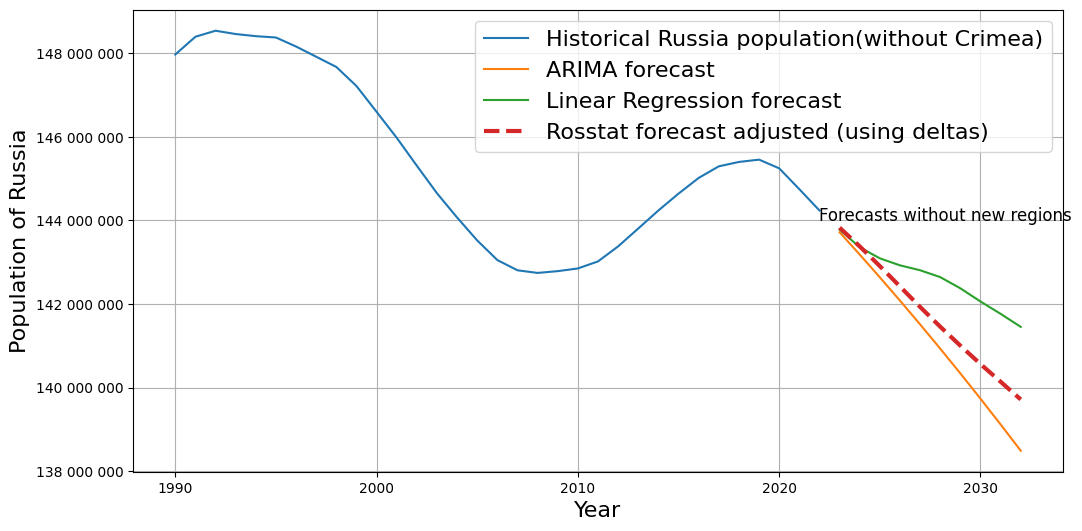

In [61]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

pred = [int(x) for x in arima_pred]
linear_pred = [int(x) for x in linear_pred]
years_forecast = list(range(2023, 2033))

plt.figure(figsize=(12, 6))

plt.plot(df_russia_pop[(df_russia_pop["year"] >= 1990) & (df_russia_pop["year"] <= 2022)]["year"], df_russia_pop[(df_russia_pop["year"] >= 1990) & (df_russia_pop["year"] <= 2022)]['Population_total'], label='Historical Russia population(without Crimea)')
plt.plot(years_forecast, pred, label='ARIMA forecast')
plt.plot(years_forecast, linear_pred, label='Linear Regression forecast')
plt.plot(years_forecast, rosstat_pred_adjusted,
         label='Rosstat forecast adjusted (using deltas)', linewidth=3, linestyle='--')
plt.text(2022, 144000000, "Forecasts without new regions", fontsize=12)

plt.xlabel('Year', fontsize = 16)
plt.ylabel('Population of Russia', fontsize = 16)

plt.legend(fontsize=16)
plt.grid(True)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " "))
)

plt.show()
